# The Rocky Translator

**Made by Yaqing Su**

*PHYS305 2026 Spring*

## Introduction:

This project uses machine learning to build a model that understands musical notes. So far, the model is only trained on one note: C4. By expanding the model to be trained on more notes, the "translator will be able to recognize more notes.

The main program is built on google colab because it provides the disk space and ram I need for this project. Other preperations were ran on a the local disk.

## methodology
The program is essentially using a convolution network (CNN) to achieve pattern recognition through analyzing "images". Spectrograms of "C4 notes" and "not C4 notes" are fed to the machine so that it can learn the frequency and patterns of the spectrograms.


⚠️***Warning***⚠️:
If you run my program, do it from the beginning and change paths to your own directories

⚠️DO NOT KEEP TAB OPEN AFTER RUNNING, IT WILL EAT UP ALL YOUR MEMORY AND STORAGE⚠️

#Set Up

This part of the project is very important. I used a list of libraries to configure the path to all of my folders and get their data. This is the backbone of the project. It includes making and saving and checking spectrogram data.

In [ ]:
# Mount drive
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Imports
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Path to your dataset
path = "/content/drive/MyDrive/Colab_Notebooks/PHYS305/FinalProject/"

# Paths to datasets
c_data_set = path + "c_training"
not_c_data_set = path + "not_c_training"
c_test_set = path + "c_test"


# Create folder if it doesn't exist
#os.makedirs(c_test_save_path, exist_ok=True)

# Paths to save spectrograms
c_save_path = path + "c_spectrograms"
not_c_save_path = path + "not_c_spectrogram"
c_test_save_path = path + "c_test_spectrogram"


# Parameters for spectrogram
sample_rate = 22050
#rows of data spectrogram?
N_mels = 128
#step forward when analyzing audio
Hop_length = 512


In [ ]:
# pick files randomly to put in the test folder

import random
import shutil

# Safety check: make sure test folder is empty
# I don't want the testing files to exist in the training one

if len(os.listdir(c_test_set)) > 0:
    print("⚠️ Test folder is NOT empty. Aborting to prevent overwriting.")
    # you can take away the if else statement and get rid of the warning,
    # and the code would still work. I just didn't want to risk anything with
    # the model.
else:
    print("Test folder is empty. Proceeding...\n")

    # Get .wav files from c and not c fodler
    c_files = [f for f in os.listdir(c_data_set) if f.endswith(".wav")]
    not_c_files = [f for f in os.listdir(not_c_data_set) if f.endswith(".wav")]

    # Randomly sample 50 from each folder
    c_sample = random.sample(c_files, min(50, len(c_files)))
    not_c_sample = random.sample(not_c_files, min(50, len(not_c_files)))

    # Move C4 files
    for file_name in c_sample:
        src = os.path.join(c_data_set, file_name)

        # Add prefix to avoid name collisions
        dst = os.path.join(c_test_set, "C4_" + file_name)
        shutil.move(src, dst)

    # Move NOT C4 files
    for file_name in not_c_sample:
        src = os.path.join(not_c_data_set, file_name)

        #rename the files for easy future debugging
        dst = os.path.join(c_test_set, "notC4_" + file_name)

        shutil.move(src, dst)
    # This helps me check which files succeeded and which ones failed,
    # so not bad data is left unchecked
    print(f"Moved {len(c_sample)} C4 files and {len(not_c_sample)} not_C4 files into test set.")

⚠️ Test folder is NOT empty. Aborting to prevent overwriting.


## making spectrograms from .wav files

This process is very self-explanatory: The function takes a wav file, retrive the signal and time stamps, convert it to a spectrogram using fourier transforms. I didn't have to define a fft specifically becasue there are better more rigorous libraries that do that.

> mel_spec = librosa.feature.melspectrogram(y=signal,sr=sr, n_fft=2048,
                                            hop_length=Hop_length,n_mels=N_mels)


This is the line of code that the fourier transform is hidden in. The melspectrogram has a short time fourier transform.

n_fft = 2048 means that the number of sampels used in each fourier transofrm window is 2048.


In [ ]:
# define wave function
# run this first
def wav_to_spectrogram(file_path):
  '''
  This function takes a .wav file and returns a log mel spectrogram.
  input:
    file_path: path to .wav file
  output:
    log_mel_spec: log mel spectrogram
  '''

  # Load audio
  signal, sr = librosa.load(file_path, sr=sample_rate)

  # crop from 0.2s to 3.8s. There are some sound files that have
  # some silence at the start.
  start_sample = int(0.2 * sample_rate)
  end_sample   = int(3.8 * sample_rate)

  # If the file is too short, pad it first
  if len(signal) < end_sample:
      padding = end_sample - len(signal)
      signal = np.pad(signal, (0, padding))

  # Crop the desired segment
  signal = signal[start_sample:end_sample]

  # Create mel spectrogram
  # THIS IS THE FOURIER TRANSFORM DONE WITH THE LIBROSA LIBRARY!!!!
  mel_spec = librosa.feature.melspectrogram(y=signal,sr=sr, n_fft=2048,
                                            hop_length=Hop_length,n_mels=N_mels)

  # Convert to log scale
  log_mel_spec = librosa.power_to_db(mel_spec)

  return log_mel_spec

In [ ]:
# we want to save our outputs
# this is done for both c4 and not c4
spectrograms = []
labels = []

# Process C4 files
for file_name in os.listdir(c_data_set):
    # if filename ends with .wav, retrieve file and make it into .npy
    if file_name.endswith(".wav"):
        file_path = os.path.join(c_data_set, file_name)

        spec = wav_to_spectrogram(file_path)

        # Save
        save_file_name = file_name.replace(".wav", ".npy")
        save_file_path = os.path.join(c_save_path, save_file_name)
        np.save(save_file_path, spec)

        # Store in memory
        spectrograms.append(spec)
        labels.append("C4")

# Process NOT C4 files
for file_name in os.listdir(not_c_data_set):
    # same logic as before
    if file_name.endswith(".wav"):
        file_path = os.path.join(not_c_data_set, file_name)

        spec = wav_to_spectrogram(file_path)

        # Save
        save_file_name = file_name.replace(".wav", ".npy")
        save_file_path = os.path.join(not_c_save_path, save_file_name)
        np.save(save_file_path, spec)

        # Store in memory
        spectrograms.append(spec)
        labels.append("not_C4")

# Convert to numpy arrays
spectrograms = np.array(spectrograms)
labels = np.array(labels)


print("Spectrogram shape:", spectrograms.shape)

Spectrogram shape: (1329, 128, 156)


In [ ]:
# Process TEST files
# Remember when we took out 50 files of each c4 and not c4?
# we want those to be spectrograms too, and saved seperately
test_spectrogram = []
test_labels = []

for file_name in os.listdir(c_test_set):
    if file_name.endswith(".wav"):
        file_path = os.path.join(c_test_set, file_name)

        # Convert to spectrogram
        spec = wav_to_spectrogram(file_path)

        # Save
        save_file_name = file_name.replace(".wav", ".npy")
        save_file_path = os.path.join(c_test_save_path, save_file_name)
        np.save(save_file_path, spec)


        # Assign label based on filename
        if file_name.startswith("C4_"):
            label = "C4"
        else:
            label = "not_C4"

        # Store
        test_spectrogram.append(spec)
        test_labels.append(label)

# Convert to numpy arrays
test_spectrogram = np.array(test_spectrogram)
test_labels = np.array(test_labels)

print("Test spectrogram shape:", test_spectrogram.shape)
print("Test labels:", np.unique(test_labels))

Test spectrogram shape: (100, 128, 156)
Test labels: ['C4' 'not_C4']


after saving the spectrograms, we want to load them so we can set up labels


In [ ]:
loaded_specs = []
loaded_labels = []

# Load C4 spectrograms
for file_name in os.listdir(c_save_path):
    if file_name.endswith(".npy"):
        file_path = os.path.join(c_save_path, file_name)

        spec = np.load(file_path)
        loaded_specs.append(spec)
        loaded_labels.append("C4")

# Load NOT C4 spectrograms
for file_name in os.listdir(not_c_save_path):
    if file_name.endswith(".npy"):
        file_path = os.path.join(not_c_save_path, file_name)

        spec = np.load(file_path)
        loaded_specs.append(spec)
        loaded_labels.append("not_C4")

# Convert to arrays
loaded_specs = np.array(loaded_specs)
loaded_labels = np.array(loaded_labels)

print("Loaded shape:", loaded_specs.shape)
print("Labels:", np.unique(loaded_labels))

Loaded shape: (1329, 128, 156)
Labels: ['C4' 'not_C4']


shuffle is an important tool so everytime we trainthe model it will be slightly different.

The output shows I have 1329 samples after taking out the 100 files for the final testing.

In [ ]:
# Shuffle
from sklearn.utils import shuffle
loaded_specs, loaded_labels = shuffle(loaded_specs, loaded_labels, random_state=42)

# Normalize
loaded_specs = (loaded_specs - np.mean(loaded_specs)) / np.std(loaded_specs)

# Add channel dimension
loaded_specs = loaded_specs[..., np.newaxis]

#Check the shape of the CNN
# (samples, height, width, channels)
print("Shape for CNN:", loaded_specs.shape)


Shape for CNN: (1329, 128, 156, 1)


## quick spectrograph check

manually check spectrograms in the folder. I just needed to see that 5 in a row were good.

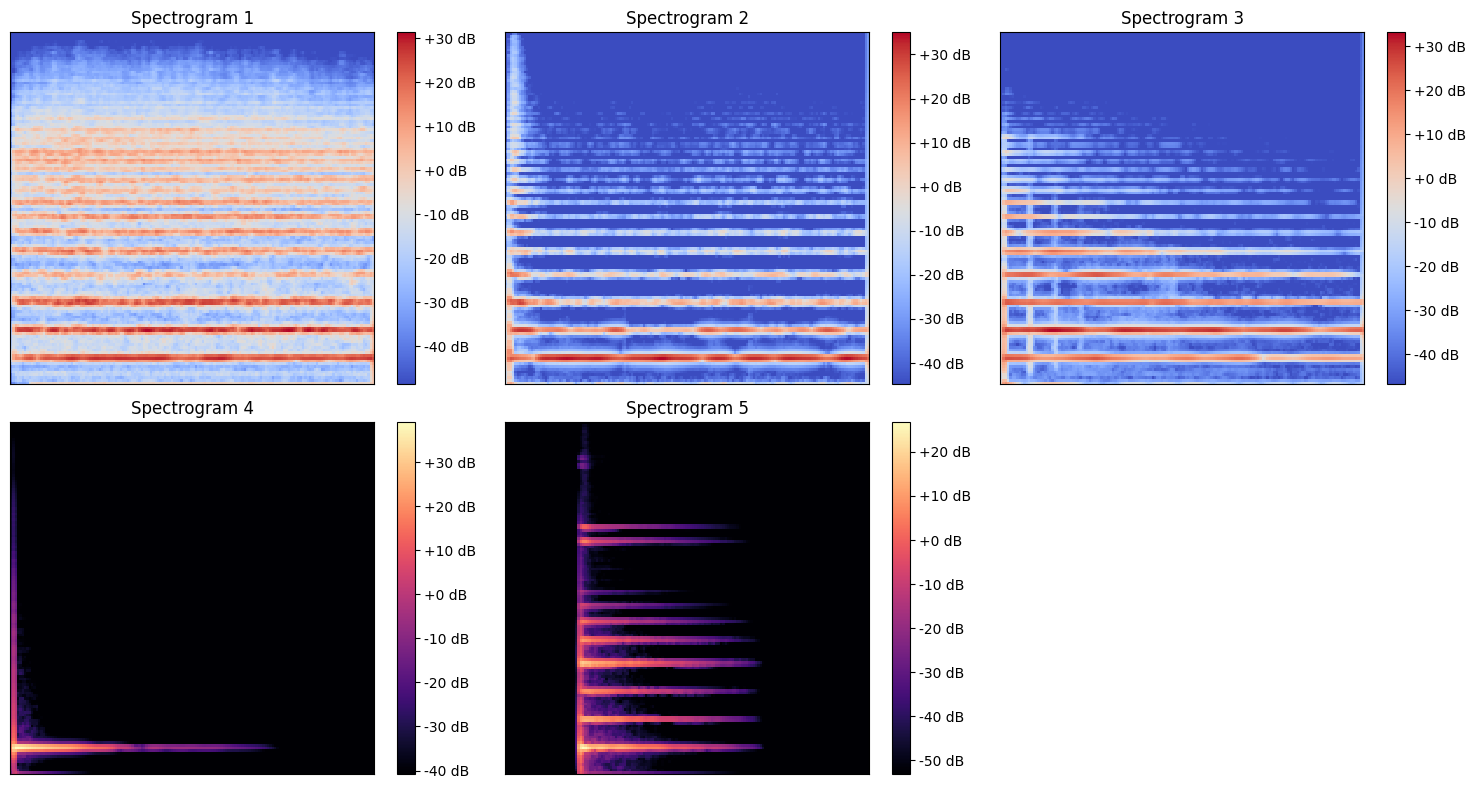

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa.display

# Path to saved spectrograms
c_save_path = path + "c_spectrograms"

# Get first 5 files
# this type of file calling is actually really helpful and concise
# I learned this technique from programmers on reddit.
files = [f for f in os.listdir(c_save_path) if f.endswith(".npy")]
files = sorted(files)[:5]

plt.figure(figsize=(15, 8))

for i, file_name in enumerate(files):
    file_path = os.path.join(c_save_path, file_name)

    # Load spectrogram
    spec = np.load(file_path)

    # Plot
    plt.subplot(2, 3, i + 1)
    librosa.display.specshow(spec, sr=sample_rate, hop_length=Hop_length)

    plt.title(f"Spectrogram {i+1}")
    plt.colorbar(format='%+2.0f dB')

plt.tight_layout()
plt.show()

Here we can see that there is a variety of file with a clear line at around 261Hz. Spectrogram 5 shows what a clean file looks like, while the other ones show multiple frequecies but a strong frequency at the expected one.

#The Machine Learning Model

To implement the training and modeling of the machine learning model, the libraries: Tensorflor and sklearn were used. This is the easiest to implement on google colab in a jupyter notebook file.

In [ ]:
#imports
import tensorflow as tf
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split


In [ ]:
#Encode lables
# Ths step is CRUCIAL for pattern recognition
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(loaded_labels)

y_categorical = to_categorical(y_encoded)

print("Classes:", label_encoder.classes_)

Classes: ['C4' 'not_C4']


In [ ]:
# Training and splitting
# here we used the same method in class
X_train, X_val, y_train, y_val = train_test_split(loaded_specs, y_categorical,
                                                  test_size=0.2,random_state=42)

print("C4 count:", np.sum(loaded_labels == "C4"))
print("not_C4 count:", np.sum(loaded_labels == "not_C4"))


C4 count: 654
not_C4 count: 675


### building the model

Using tensorflow.keras, it is possible to build a model with 3 convolution laryers, one flattening and dense layers, a dropout layer, and 3 max pooling layers.

In [ ]:
from tensorflow.keras import layers, models

# Input shape = (height, width, channels)
input_shape = X_train.shape[1:]

model = models.Sequential([

    # Convolution Block 1
    layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),

    # Convolution Block 2
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Convolution Block 3
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    # Flatten + Dense layers
    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  # helps prevent overfitting

    # Output layer (2 classes: C4, not_C4)
    layers.Dense(y_categorical.shape[1], activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# this block shows what the model is composed of and prints out a table summary.
model.compile(optimizer='adam', loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 154, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 77, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 35, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30464)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,899,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,992,450 (15.23 MB)

 Trainable params: 3,992,450 (15.23 MB)

 Non-trainable params: 0 (0.00 B)

### Training Time!
I tested my model on 50 epochs (patience running low).

I sued a batch size of 16 because it is apparently the recommended industry standard a few youtubers are using.

In [ ]:
# here I also used x_vals and y_vals like we did in class
history = model.fit(X_train, y_train, validation_data=(X_val, y_val),
                    epochs=50,
                    batch_size=16, verbose=1)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 46s 641ms/step - accuracy: 0.8617 - loss: 0.3681 - val_accuracy: 0.9398 - val_loss: 0.1410
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 43s 637ms/step - accuracy: 0.9614 - loss: 0.1322 - val_accuracy: 0.9699 - val_loss: 0.0633
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 81s 623ms/step - accuracy: 0.9690 - loss: 0.0897 - val_accuracy: 0.9398 - val_loss: 0.1363
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 83s 641ms/step - accuracy: 0.9812 - loss: 0.0578 - val_accuracy: 1.0000 - val_loss: 0.0118
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 40s 596ms/step - accuracy: 0.9925 - loss: 0.0305 - val_accuracy: 0.9887 - val_loss: 0.0209
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 41s 592ms/step - accuracy: 0.9915 - loss: 0.0366 - val_accuracy: 0.9662 - val_loss: 0.0638
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 47s 703ms/step - accuracy: 0.9915 - loss: 0.0291 - val_accuracy: 0.9887 - val_loss: 0.0341
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 41s 615ms/step - accuracy: 0.9953 - loss: 0.0149 - val_accu

### Results

I want to plot the training vs validation loss of the training to see how well my model recieved information. We also want to look at the training vs validation accuracy graph to make sure the model is learning what is c4 correctly and actually learning.

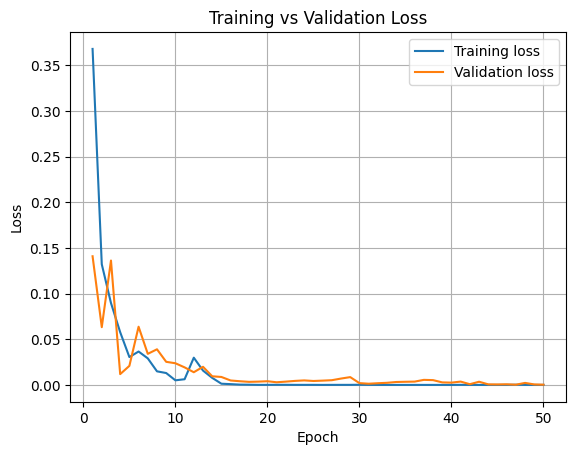

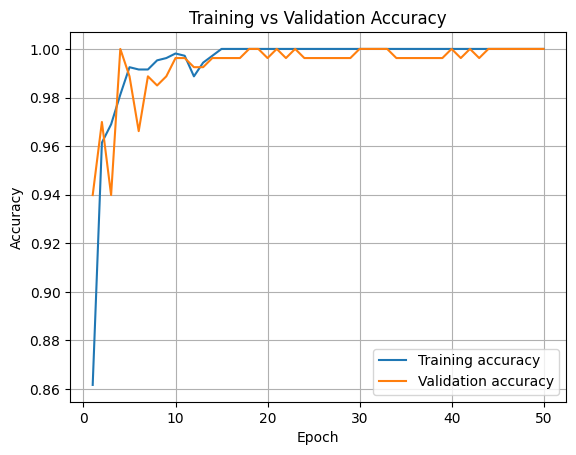

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['loss']) + 1)

# Loss
plt.figure()
plt.plot(epochs, history.history['loss'], label='Training loss')
plt.plot(epochs, history.history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

# Accuracy
plt.figure()
plt.plot(epochs, history.history['accuracy'], label='Training accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()


In [ ]:
# .evaluate helps calculate the accuracy and loss of the trianing and give
# me something numerical instead of graphical
val_loss, val_acc = model.evaluate(X_val, y_val)
print("Validation Accuracy:", val_acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 393ms/step - accuracy: 1.0000 - loss: 2.5227e-04
Validation Accuracy: 1.0


# Confusion Matrix and Predictions

The confusion matrix shows what the model predicts.

It shows true positive (Correct detection),
false positive (False alarm),
and false negative (Missed detection)
true negative (Correct rejection).

Accuracy = $ \frac{(TP + TN)}{(TP + TN + FP + FN)}$

In [ ]:
import numpy as np
# Make predictions

# Predict probabilities
y_prob = model.predict(X_val)

# Convert to class predictions
y_pred = np.argmax(y_prob, axis=1)

# Convert true labels from one-hot
y_true = np.argmax(y_val, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 336ms/step


In [1]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix! This is pretty self explanatory (see report)
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# The output of this cell was not saved after logging out of google colab :(


This is what the output of this block should look like for the current configuration:

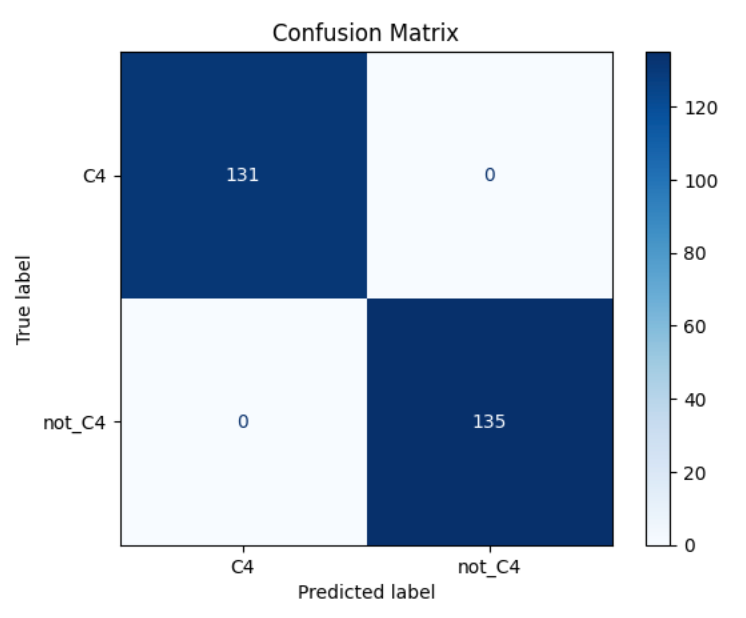

In [ ]:
# inspecting the predictions
print("\nSample predictions:\n")
# I want to look at the first 20 predictions
# I also ran it for 266 files

for i in range(20):
    print(
        f"True: {label_encoder.classes_[y_true[i]]:6s} | "
        f"Pred: {label_encoder.classes_[y_pred[i]]:6s} | "
        f"Prob: {y_prob[i]}"
    )


Sample predictions:

True: C4     | Pred: C4     | Prob: [9.9999994e-01 6.3312383e-10]
True: C4     | Pred: C4     | Prob: [9.9999994e-01 2.6209961e-11]
True: C4     | Pred: C4     | Prob: [9.9998659e-01 1.3346943e-05]
True: C4     | Pred: C4     | Prob: [9.9999994e-01 3.3739380e-13]
True: C4     | Pred: C4     | Prob: [9.9999517e-01 4.7676617e-06]
True: C4     | Pred: C4     | Prob: [9.9999994e-01 1.3355663e-09]
True: C4     | Pred: C4     | Prob: [9.9999994e-01 2.9323655e-11]
True: C4     | Pred: C4     | Prob: [9.9999994e-01 1.7581289e-09]
True: C4     | Pred: C4     | Prob: [9.9999994e-01 4.4020780e-11]
True: C4     | Pred: C4     | Prob: [9.9999994e-01 1.5693913e-14]
True: not_C4 | Pred: not_C4 | Prob: [8.6324167e-07 9.9999911e-01]
True: C4     | Pred: C4     | Prob: [9.9999994e-01 8.2040621e-15]
True: not_C4 | Pred: not_C4 | Prob: [4.8058042e-22 9.9999994e-01]
True: C4     | Pred: C4     | Prob: [9.9999994e-01 1.7041109e-10]
True: C4     | Pred: C4     | Prob: [9.9999994e-01 8.8

## Using manually made c4 folder for final testing

Once again, the confusion matrix set up used in this project has the same overall structure as the one from in class practices.

In [ ]:
# Normalize (same as training)
test_specs = (test_spectrogram - np.mean(test_spectrogram)) / np.std(test_spectrogram)

# Add channel dimension
test_specs = test_specs[..., np.newaxis]

print("Test shape:", test_specs.shape)

Test shape: (100, 128, 156, 1)


In [ ]:
# Convert labels to integers
y_test_encoded = label_encoder.transform(test_labels)

In [ ]:
import numpy as np

# Predict probabilities
y_prob = model.predict(test_specs)

# Convert to predicted class indices
y_pred = np.argmax(y_prob, axis=1)

# True labels
y_true = y_test_encoded

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 377ms/step


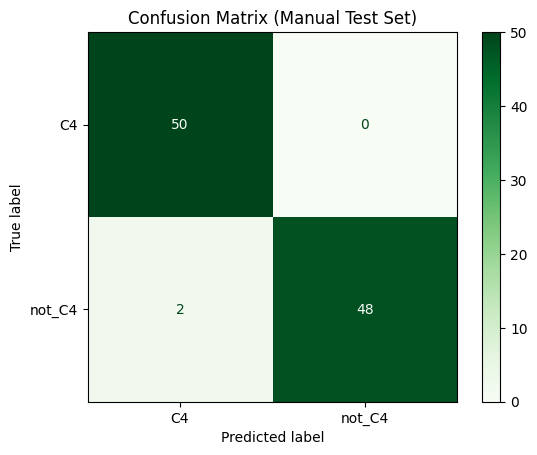

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(cmap='Greens')
plt.title("Confusion Matrix (Manual Test Set)")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
# Once again, a numerical report can be helpful
print(classification_report(
    y_true,
    y_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

          C4       0.96      1.00      0.98        50
      not_C4       1.00      0.96      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



# Relating C4 to Hello

This part of the code uses the trained algorithm to display the word "Hello" if it thinks the note in the "translate_this" folder is C4. This is the actual "translator" part of the project.

In [ ]:
# load the "translate this" folder

translate_path = path + "translate_this"

# Get the file (assuming only one .wav file inside)
file_list = [f for f in os.listdir(translate_path) if f.endswith(".wav")]

if len(file_list) == 0:
    raise ValueError("No .wav file found in translate_this folder")

file_name = file_list[0]
file_path = os.path.join(translate_path, file_name)

print("Processing file:", file_name)

Processing file: cheap organ translate.wav


In [ ]:
# Convert to spectrogram
spec = wav_to_spectrogram(file_path)

# Normalize using same method as before
spec = (spec - np.mean(spec)) / np.std(spec)

In [ ]:
# Add channel dimension
spec = spec[..., np.newaxis]

# Add batch dimension
spec = np.expand_dims(spec, axis=0)

print("Input shape to model:", spec.shape)

Input shape to model: (1, 128, 156, 1)


we have to use the model to predict just the file in the "translate this" folder.

In [ ]:
# Predict
prob = model.predict(spec)

# Get predicted class index
pred_class = np.argmax(prob, axis=1)[0]

# Convert back to label
pred_label = label_encoder.inverse_transform([pred_class])[0]

print("Prediction:", pred_label)
print("Probabilities:", prob)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Prediction: C4
Probabilities: [[1.0000000e+00 2.0480178e-09]]


In [ ]:
# check result before displaying
if pred_label == "C4":
    print("\n🎉 Hello 🎉")
else:
    print("\nNot C4")


🎉 Hello 🎉


### Now for the WOW!

The first version plays the note in my "translate this" folder and displays the word hello.  

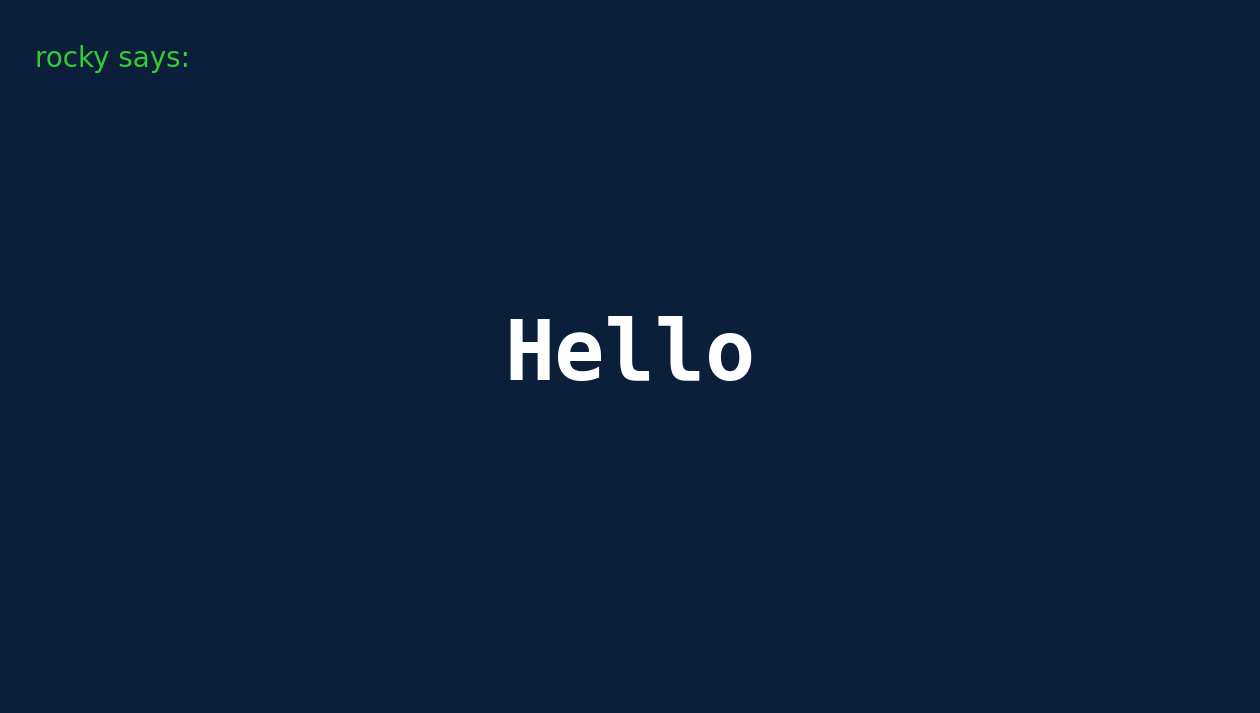

In [ ]:
from IPython.display import Audio, display
import matplotlib.pyplot as plt

# Play audio
display(Audio(file_path, autoplay=True))

# Choose text based on prediction
# very easy, if C4, main text = C4, else, text is Not C4
# This way of wording is what was suggested while using IPython
# I tried writing if else statements the normal way but it didn't really work
main_text = "Hello" if pred_label == "C4" else "Not C4"

# Create figure
fig, ax = plt.subplots(figsize=(16,9))

# Set background color (dark blue)
fig.patch.set_facecolor('#0b1f3a') # whole figure
ax.set_facecolor('#0b1f3a') # plot area

# Top-left label (green)
ax.text(
    0.02, 0.95,
    "rocky says:",
    fontsize=20,
    color='limegreen',
    ha='left',
    va='top'
)

# Main text (white, sci-fi style)
ax.text(
    0.5, 0.5,
    main_text,
    fontsize=60,
    color='white',
    ha='center',
    va='center',
    fontfamily='monospace',
    weight='bold'
)

# Remove axes
ax.axis('off')

plt.show()

### Version 2 of WOW!

This version uses text to speech. I have to install the gTTS library first.

In [ ]:
# run this if no gTTS
!pip install gTTS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 2.5 MB/s eta 0:00:00
  Attempting uninstall: click
    Found existing installation: click 8.3.3
    Uninstalling click-8.3.3:
      Successfully uninstalled click-8.3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.2 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.


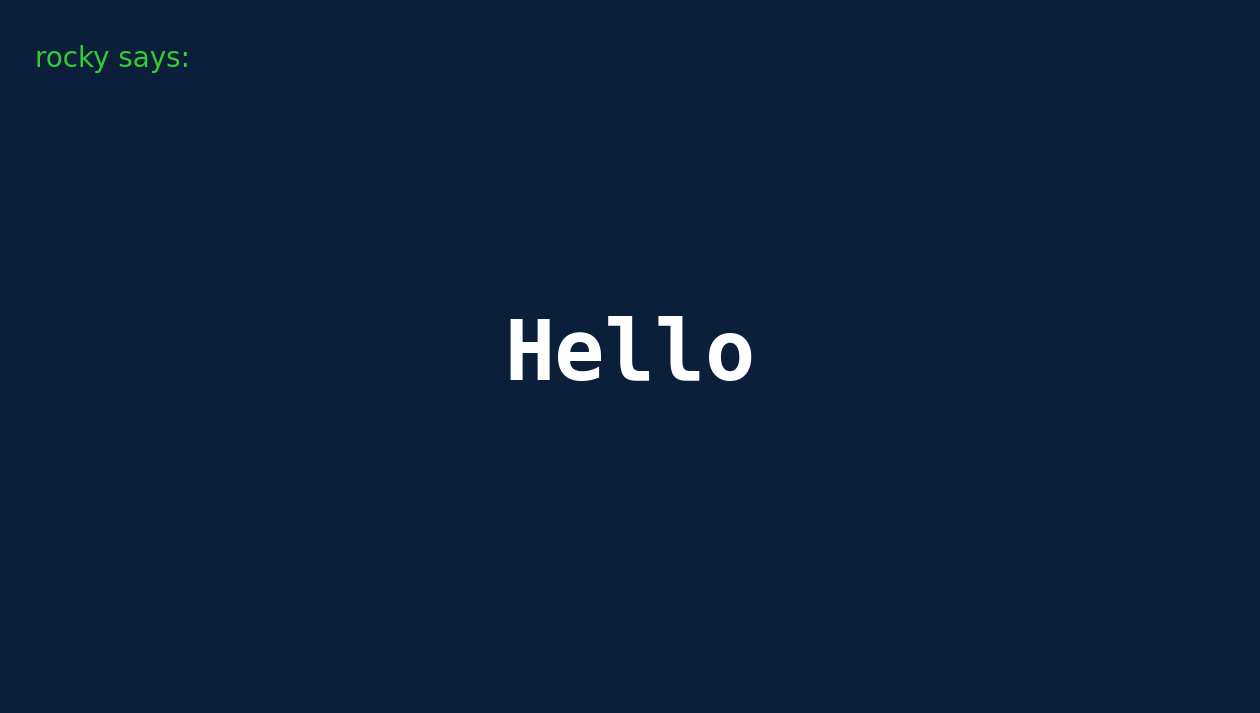

In [ ]:
from gtts import gTTS
from IPython.display import Audio, display
import matplotlib.pyplot as plt
import os

# Choose text based on prediction
# same weird wording
main_text = "Hello" if pred_label == "C4" else "Not C4"

# Generate voice
tts = gTTS(text=main_text, lang='en')

# Save temporary audio file
tts_file = "tts_output.mp3"
tts.save(tts_file)

# Play generated voice
display(Audio(tts_file, autoplay=True))

# Display UI
fig, ax = plt.subplots(figsize=(16,9))

# Background color
fig.patch.set_facecolor('#0b1f3a')
ax.set_facecolor('#0b1f3a')

# Top-left label
ax.text(
    0.02, 0.95,
    "rocky says:",
    fontsize=20,
    color='limegreen',
    ha='left',
    va='top'
)

# Main text
ax.text(
    0.5, 0.5,
    main_text,
    fontsize=60,
    color='white',
    ha='center',
    va='center',
    fontfamily='monospace',
    weight='bold'
)

ax.axis('off')
plt.show()

# clean up file (I learned this is good practice )
if os.path.exists(tts_file):
    os.remove(tts_file)